# Neighborhood Predictability Analysis

This notebook estimates how much curvature-predictive information is present in local cell neighborhoods of increasing GNN radius, after allowing the model to use global organoid features. The analysis is about predictability, not causality: a model can exploit correlations in cell state and geometry without proving that those cells caused the local curvature.

The workflow mirrors `experiments/train_single_model.ipynb` for data loading, filtering, target transforms, train/validation splitting by organoid, and model training. Region labels derived from `d_crypts_graph` are kept only for post hoc analysis and visualization; they are not passed as model inputs.


**Setup**

Import shared libraries and define paths relative to the project root, following the project notebook convention.


In [2]:
import copy
import json
import math
import pickle
import random
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Configuration**

The target is raw curvature. Models are trained in the transformed target space, as in the training notebook, but predictions are inverse-transformed back to raw curvature before every reported metric.

The `timepoint` entry is currently `None`, meaning all available non-excluded timepoints after the standard filters. Later, this cell can be wrapped in a loop over timepoints without changing the summary dataframe schemas.


In [3]:
# Data and target settings
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False  # keep reported target as raw curvature, not residual curvature

# Optional timepoint handling. None means use the standard train notebook behavior.
SELECTED_TIMEPOINT = None
EXCLUDED_TIMEPOINTS = {"day3p5"}
TIMEPOINT_LABEL = SELECTED_TIMEPOINT if SELECTED_TIMEPOINT is not None else "single_timepoint"

# Filtering and preprocessing settings from train_single_model.ipynb / dcrypt notebook.
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split settings. Splitting is by organoid metadata key, never by individual cells.
VAL_FRAC = 0.2
SPLIT_SEED = None
FORCED_VAL_KEYS = {
    ("20251201", "day4p5_B03_144"),
}

# Region settings derived from d_crypts_graph.
DCRYPT_FIELD = "d_crypts_graph"
REGION_COL = "region"
REGION_ORDER = ["all", "crypt", "neck", "villus"]
DCRYPT_CRYPT_MAX = 0.75
DCRYPT_NECK_MAX = 1.20
NO_CRYPT_REGION = "villus"

# Neighborhood radii/depths to compare. Radius 0 is the center-cell + global-features model.
RADII = [0, 1, 2, 3, 4]
K_VALUES = [25, 50, 100]
DEFAULT_K = 50

# Global features promoted to graph.global_feat by src.data.metadata utilities.
GLOBAL_FEATURE_NAMES = [
    "log_surface_area",
    "log_volume",
    "log_volume_over_area",
    "log_num_cells",
]
TARGET_COLUMN = "raw_curvature"
ORGANOID_ID_COLUMN = "organoid_id"
CELL_ID_COLUMN = "cell_id"

# Model settings
MODEL_CLASS = "GINCurvature"
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
BASELINE_HIDDEN_DIM = HIDDEN_DIM

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Output settings
EXPERIMENT_GROUP = "neighborhood_predictability_analysis"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
MODELS_DIR = SAVE_DIR / "models"

# Optional cache loading. Leave false unless MODEL_CACHE_DIR was produced by an equivalent run.
LOAD_MODEL_CACHE = False
MODEL_CACHE_DIR = None

CONFIG = {
    "timepoint": SELECTED_TIMEPOINT,
    "timepoint_label": TIMEPOINT_LABEL,
    "radii": RADII,
    "regions": REGION_ORDER,
    "target": TARGET_COLUMN,
    "target_indices": TARGET_INDICES,
    "organoid_id": ORGANOID_ID_COLUMN,
    "cell_id": CELL_ID_COLUMN,
    "region_col": REGION_COL,
    "dcrypt_field": DCRYPT_FIELD,
    "dcrypt_thresholds": {"crypt_max": DCRYPT_CRYPT_MAX, "neck_max": DCRYPT_NECK_MAX},
    "no_crypt_region": NO_CRYPT_REGION,
    "global_features": GLOBAL_FEATURE_NAMES,
    "random_seed": 42,
    "k_values": K_VALUES,
    "default_k": DEFAULT_K,
    "output_dir": str(SAVE_DIR),
}

SAVE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG


{'timepoint': None,
 'timepoint_label': 'single_timepoint',
 'radii': [0, 1, 2, 3, 4],
 'regions': ['all', 'crypt', 'neck', 'villus'],
 'target': 'raw_curvature',
 'target_indices': [0],
 'organoid_id': 'organoid_id',
 'cell_id': 'cell_id',
 'region_col': 'region',
 'dcrypt_field': 'd_crypts_graph',
 'dcrypt_thresholds': {'crypt_max': 0.75, 'neck_max': 1.2},
 'no_crypt_region': 'villus',
 'global_features': ['log_surface_area',
  'log_volume',
  'log_volume_over_area',
  'log_num_cells'],
 'random_seed': 42,
 'k_values': [25, 50, 100],
 'default_k': 50,
 'output_dir': '/home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744'}

**Small Helpers**

These helpers keep the notebook focused on the analysis instead of reimplementing project internals. Metrics are computed on raw curvature after inverse transformation.


In [4]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_random_seed(CONFIG["random_seed"])


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    n = int(y_true.size)
    if n == 0:
        return {"mse": np.nan, "rmse": np.nan, "mae": np.nan, "r2": np.nan, "n_cells": 0}
    resid = y_true - y_pred
    mse = float(np.mean(resid ** 2))
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(np.mean(np.abs(resid))),
        "r2": float(r2) if np.isfinite(r2) else np.nan,
        "n_cells": n,
    }


def compute_grouped_metrics(df, pred_col, group_col=REGION_COL, true_col="y_true"):
    rows = []
    for region in REGION_ORDER:
        sub = df if region == "all" else df[df[group_col] == region]
        row = {
            "timepoint": TIMEPOINT_LABEL,
            "region": region,
            "model_name": pred_col,
            "n_organoids": int(sub[ORGANOID_ID_COLUMN].nunique()) if len(sub) else 0,
        }
        row.update(compute_regression_metrics(sub[true_col], sub[pred_col]))
        rows.append(row)
    return pd.DataFrame(rows)


def save_mpl_figure(fig, name, *, dpi=300):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    paths = []
    for suffix in ["png", "pdf"]:
        path = FIGURES_DIR / f"{name}.{suffix}"
        fig.savefig(path, bbox_inches="tight", dpi=dpi)
        paths.append(path)
    print("Saved figure ->", paths[0], "and", paths[1])
    return paths


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    return obj


## 1. Load, Filter, Transform, And Split Data

The validation split is made at the organoid level. This matters because cells from the same organoid share history, imaging conditions, global geometry, and preprocessing context. A cell-level split would let the model see almost the same organoid during training and validation, inflating estimates of local predictability.


In [5]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)


Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids.
Raw y shape: (165, 2)
Attached metadata to 1423/1423 graphs.
Selected y shape: (165,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [6]:
# Timepoint filtering. The default follows train_single_model.ipynb and drops day3p5 if present.
if SELECTED_TIMEPOINT is not None:
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={SELECTED_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif EXCLUDED_TIMEPOINTS:
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values=set(EXCLUDED_TIMEPOINTS),
        missing="keep",
        inplace=False,
        print_summary=True,
    )


filter_graphs_by_metadata(key='timepoint'): kept 1134 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    289    0.000
20250929         day4                342    342    1.000
20250929         day4p5              104    104    1.000
20250929         day4p5-more         411    411    1.000
20251201         day4p5              277    277    1.000


In [7]:
if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

# Keep this commented to match train_single_model.ipynb exactly. Uncomment to reproduce dcrypt notebook's spherical rescue.
# graphs = graphs + g_spherical
print(f"After filtering: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                243    341    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         288    409    0.704
20251201         day4p5              193    274    0.704
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 91 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------

In [8]:
field_specs = [
    {
        "meta_keys": GLOBAL_FEATURE_NAMES,
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


In [9]:
g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_keys = {graph_metadata_key(g) for g in g_train}
val_keys = {graph_metadata_key(g) for g in g_val}
overlap = train_keys & val_keys
assert not overlap, f"Organoid-level split leakage: {overlap}"

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

# Strip metadata before batching, after saving a lookup for region and organoid-level analysis.
g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    if not USE_GLOBAL_FEATURES:
        raise ValueError("SUBTRACT_CONSTANT_GLOBAL_BASELINE requires USE_GLOBAL_FEATURES=True.")
    baseline_residual_transform = GlobalBaselineResidualTransform(num_workers=NUM_WORKERS)
    target_transform = ChainedTargetTransform([
        baseline_residual_transform,
        AsinhStandardizeTransform(robust=True),
    ])
    training_target_description = "target residual: true curvature - global-feature baseline"
else:
    baseline_residual_transform = None
    target_transform = AsinhStandardizeTransform(robust=True)
    training_target_description = "raw target"

print("Training target:", training_target_description)
target_transform.fit(g_train)
target_transform.transform_graphs(g_train, in_place=True)
target_transform.transform_graphs(g_val, in_place=True)

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)


Split -> train: 565 | val: 141
Training target: raw target
global_dim = 4
target_transform = asinh_standardize


**Region Metadata**

The region label is derived from the metadata field `d_crypts_graph`, following the approach in `dcrypt_region_marker_informativeness.ipynb`: each node receives the minimum finite distance to a crypt graph. We convert that continuous distance to `crypt`, `neck`, or `villus` only after the model has made predictions.

Cells without a finite crypt distance are assigned to `NO_CRYPT_REGION` for this three-region analysis. The count is reported so this choice is visible.


In [10]:
from src.data.metadata import get_graph_metadata


def nanmin_or_nan(values, axis):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    filled = np.where(finite, arr, np.inf)
    out = np.min(filled, axis=axis)
    has_finite = np.any(finite, axis=axis)
    out = np.asarray(out, dtype=float)
    out[~has_finite] = np.nan
    return out


def min_node_dcrypt_from_raw(raw, n_nodes):
    arr = np.asarray(raw, dtype=float)
    if arr.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    if arr.ndim == 0:
        return np.full(n_nodes, float(arr), dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] == n_nodes:
            return arr.astype(float)
        if arr.shape[0] == 1:
            return np.full(n_nodes, float(arr[0]), dtype=float)
        raise ValueError(f"Cannot align 1-D dcrypt with length {arr.shape[0]} to {n_nodes} nodes.")
    if n_nodes in arr.shape:
        node_axis = list(arr.shape).index(n_nodes)
        moved = np.moveaxis(arr, node_axis, 0).reshape(n_nodes, -1)
        return nanmin_or_nan(moved, axis=1)
    if arr.ndim >= 2 and arr.shape[1] >= n_nodes:
        vals = nanmin_or_nan(arr, axis=0)
    else:
        vals = nanmin_or_nan(arr, axis=1)
    vals = np.asarray(vals, dtype=float).reshape(-1)
    if vals.shape[0] != n_nodes:
        raise ValueError(f"Transformed dcrypt has length {vals.shape[0]}, expected {n_nodes}.")
    return vals


def compute_min_dcrypt_by_graphs(graphs_in, *, meta_lookup, field=DCRYPT_FIELD):
    values_by_graph = []
    for g in graphs_in:
        n_nodes = int(g.y.shape[0])
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=False, default={})
        raw = md.get(field, np.asarray([], dtype=float))
        values_by_graph.append(min_node_dcrypt_from_raw(raw, n_nodes))
    flat = np.concatenate(values_by_graph, axis=0) if values_by_graph else np.asarray([], dtype=float)
    return values_by_graph, flat


def dcrypt_to_region(dcrypt_values):
    d = np.asarray(dcrypt_values, dtype=float).reshape(-1)
    region = np.full(d.shape[0], NO_CRYPT_REGION, dtype=object)
    finite = np.isfinite(d)
    region[finite & (d < DCRYPT_CRYPT_MAX)] = "crypt"
    region[finite & (d >= DCRYPT_CRYPT_MAX) & (d <= DCRYPT_NECK_MAX)] = "neck"
    region[finite & (d > DCRYPT_NECK_MAX)] = "villus"
    return region


train_dcrypt_by_graph, train_dcrypt = compute_min_dcrypt_by_graphs(g_train, meta_lookup=train_meta_lookup)
val_dcrypt_by_graph, val_dcrypt = compute_min_dcrypt_by_graphs(g_val, meta_lookup=val_meta_lookup)
train_region = dcrypt_to_region(train_dcrypt)
val_region = dcrypt_to_region(val_dcrypt)

region_count_df = pd.DataFrame([
    {
        "split": split,
        "region": region,
        "n_cells": int(np.sum(labels == region)),
        "n_without_finite_dcrypt": int(np.sum(~np.isfinite(dcrypt))),
    }
    for split, labels, dcrypt in [
        ("train", train_region, train_dcrypt),
        ("val", val_region, val_dcrypt),
    ]
    for region in ["crypt", "neck", "villus"]
])
display(region_count_df)

assert set(pd.unique(val_region)).issubset({"crypt", "neck", "villus"})
assert REGION_COL not in GLOBAL_FEATURE_NAMES, "Region labels must not be included in model global features."


,split,region,n_cells,n_without_finite_dcrypt
0,train,crypt,52208,21001
1,train,neck,69394,21001
2,train,villus,141409,21001
3,val,crypt,16476,3324
4,val,neck,21825,3324
5,val,villus,37071,3324


In [11]:
def graph_global_feature_matrix(graphs_in):
    rows = []
    for g in graphs_in:
        n = int(g.y.shape[0])
        if USE_GLOBAL_FEATURES and hasattr(g, "global_feat"):
            vals = g.global_feat.detach().cpu().numpy().reshape(1, -1)
            rows.append(np.repeat(vals, n, axis=0))
        else:
            rows.append(np.empty((n, 0), dtype=float))
    return np.concatenate(rows, axis=0) if rows else np.empty((0, 0), dtype=float)


def build_node_metadata_dataframe(graphs_in, *, meta_lookup, split, dcrypt_values, region_labels):
    rows = []
    offset = 0
    gfeat = graph_global_feature_matrix(graphs_in)
    for gi, g in enumerate(graphs_in):
        n = int(g.y.shape[0])
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=False, default={})
        organoid_id = md.get("organoid_id", getattr(g, "organoid_str", None))
        organoid_str = getattr(g, "organoid_str", organoid_id)
        for node_idx in range(n):
            flat_idx = offset + node_idx
            row = {
                "timepoint": md.get("timepoint", TIMEPOINT_LABEL),
                "analysis_timepoint": TIMEPOINT_LABEL,
                "split": split,
                "graph_index": gi,
                "node_index": node_idx,
                CELL_ID_COLUMN: f"{organoid_str}:{node_idx}",
                ORGANOID_ID_COLUMN: organoid_id,
                "organoid_str": organoid_str,
                REGION_COL: str(region_labels[flat_idx]),
                "dcrypt_min": float(dcrypt_values[flat_idx]) if np.isfinite(dcrypt_values[flat_idx]) else np.nan,
            }
            for j, name in enumerate(GLOBAL_FEATURE_NAMES[:gfeat.shape[1]]):
                row[name] = float(gfeat[flat_idx, j])
            rows.append(row)
        offset += n
    return pd.DataFrame(rows)


train_metadata_df = build_node_metadata_dataframe(
    g_train,
    meta_lookup=train_meta_lookup,
    split="train",
    dcrypt_values=train_dcrypt,
    region_labels=train_region,
)
val_metadata_df = build_node_metadata_dataframe(
    g_val,
    meta_lookup=val_meta_lookup,
    split="val",
    dcrypt_values=val_dcrypt,
    region_labels=val_region,
)

display(val_metadata_df.head())
print("Train cells:", len(train_metadata_df), "Val cells:", len(val_metadata_df))


,timepoint,analysis_timepoint,split,graph_index,node_index,cell_id,organoid_id,organoid_str,region,dcrypt_min,log_surface_area,log_volume,log_volume_over_area,log_num_cells
0,day4,single_timepoint,val,0,0,organoid_day4_A02_16:0,day4_A02_16,organoid_day4_A02_16,neck,0.958427,-0.299139,-0.304445,-0.271724,-0.547203
1,day4,single_timepoint,val,0,1,organoid_day4_A02_16:1,day4_A02_16,organoid_day4_A02_16,villus,1.797089,-0.299139,-0.304445,-0.271724,-0.547203
2,day4,single_timepoint,val,0,2,organoid_day4_A02_16:2,day4_A02_16,organoid_day4_A02_16,villus,1.366774,-0.299139,-0.304445,-0.271724,-0.547203
3,day4,single_timepoint,val,0,3,organoid_day4_A02_16:3,day4_A02_16,organoid_day4_A02_16,neck,1.096028,-0.299139,-0.304445,-0.271724,-0.547203
4,day4,single_timepoint,val,0,4,organoid_day4_A02_16:4,day4_A02_16,organoid_day4_A02_16,crypt,0.671338,-0.299139,-0.304445,-0.271724,-0.547203


Train cells: 263011 Val cells: 75372


## 2. Train Or Load Baseline And GNN Models

The global-only baseline captures curvature information due to organoid size and global geometry. The center-cell baseline adds the marker state of the focal cell but no neighborhood message passing. GNN radii/depths then test how much additional information is gained by aggregating neighbors.


In [12]:
from src.models.baseline import GlobalFeatureMLP
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


def infer_target_dim_from_graphs(graphs_in):
    y = graphs_in[0].y
    return 1 if y.ndim == 1 else int(y.shape[1])


target_dim = infer_target_dim_from_graphs(g_train)
if global_dim < 1:
    raise ValueError("This analysis requires USE_GLOBAL_FEATURES=True and attached global_feat tensors.")


device = cuda


In [13]:
def model_state_path(model_name):
    cache_dir = Path(MODEL_CACHE_DIR) if LOAD_MODEL_CACHE and MODEL_CACHE_DIR is not None else MODELS_DIR
    return cache_dir / f"{model_name}.pt"


def train_or_load_model(model, model_name, train_graphs, val_graphs, cfg):
    load_path = model_state_path(model_name)
    history = None
    metrics = None
    if LOAD_MODEL_CACHE and load_path.exists():
        print(f"Loading {model_name} from {load_path}")
        state = torch.load(load_path, map_location="cpu")
        model.load_state_dict(state["model_state_dict"] if isinstance(state, dict) and "model_state_dict" in state else state)
        if isinstance(state, dict):
            metrics = state.get("metrics")
            history = state.get("history")
        return model, metrics, history

    print(f"Training {model_name}")
    model, metrics, history = train(model, train_graphs, val_graphs, cfg)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "metrics": metrics,
            "history": history,
            "config": jsonable(CONFIG),
        },
        MODELS_DIR / f"{model_name}.pt",
    )
    return model, metrics, history


global_baseline_model = GlobalFeatureMLP(
    global_dim=global_dim,
    hidden_dim=BASELINE_HIDDEN_DIM,
    dropout=DROPOUT,
    target_dim=target_dim,
)
global_baseline_model, metrics_global_baseline, history_global_baseline = train_or_load_model(
    global_baseline_model,
    "global_only_baseline",
    g_train,
    g_val,
    cfg,
)

center_global_model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=0,
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
    target_dim=target_dim,
)
center_global_model, metrics_center_global, history_center_global = train_or_load_model(
    center_global_model,
    "center_cell_global_baseline",
    g_train,
    g_val,
    cfg,
)


Training global_only_baseline
epoch 001 | train loss 0.5095 mae 0.7621 | val loss 0.5043 mae 0.7644
epoch 002 | train loss 0.4887 mae 0.7463 | val loss 0.4885 mae 0.7584
epoch 003 | train loss 0.4726 mae 0.7424 | val loss 0.4763 mae 0.7598
epoch 004 | train loss 0.4607 mae 0.7442 | val loss 0.4691 mae 0.7625
epoch 005 | train loss 0.4514 mae 0.7439 | val loss 0.4624 mae 0.7596
epoch 006 | train loss 0.4452 mae 0.7415 | val loss 0.4590 mae 0.7582
epoch 007 | train loss 0.4407 mae 0.7413 | val loss 0.4579 mae 0.7598
epoch 008 | train loss 0.4375 mae 0.7414 | val loss 0.4557 mae 0.7588
epoch 009 | train loss 0.4355 mae 0.7411 | val loss 0.4546 mae 0.7581
epoch 010 | train loss 0.4337 mae 0.7402 | val loss 0.4546 mae 0.7576
epoch 011 | train loss 0.4323 mae 0.7403 | val loss 0.4526 mae 0.7578
epoch 012 | train loss 0.4313 mae 0.7406 | val loss 0.4507 mae 0.7578
epoch 013 | train loss 0.4306 mae 0.7404 | val loss 0.4504 mae 0.7575
epoch 014 | train loss 0.4293 mae 0.7402 | val loss 0.4499 m

In [14]:
gnn_models = {0: center_global_model}
gnn_training_logs = {
    0: {
        "model_name": "center_cell_global_baseline",
        "metrics": metrics_center_global,
        "history": history_center_global,
    }
}

for radius in RADII:
    radius = int(radius)
    if radius == 0:
        continue
    model = GINCurvature(
        n_markers=int(g_train[0].x.size(1)),
        global_dim=infer_global_dim(g_train),
        hidden_dim=HIDDEN_DIM,
        num_layers=radius,
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
        target_dim=target_dim,
    )
    model, metrics, history = train_or_load_model(
        model,
        f"gnn_radius_{radius}",
        g_train,
        g_val,
        cfg,
    )
    gnn_models[radius] = model
    gnn_training_logs[radius] = {
        "model_name": f"gnn_radius_{radius}",
        "metrics": metrics,
        "history": history,
    }

print("Trained/loaded radii:", sorted(gnn_models))


Training gnn_radius_1
epoch 001 | train loss 0.5193 mae 0.7812 | val loss 0.5087 mae 0.7799
epoch 002 | train loss 0.4735 mae 0.7434 | val loss 0.4842 mae 0.7599
epoch 003 | train loss 0.4502 mae 0.7264 | val loss 0.4629 mae 0.7441
epoch 004 | train loss 0.4332 mae 0.7149 | val loss 0.4353 mae 0.7281
epoch 005 | train loss 0.4234 mae 0.7061 | val loss 0.4220 mae 0.7209
epoch 006 | train loss 0.4144 mae 0.7025 | val loss 0.4174 mae 0.7117
epoch 007 | train loss 0.4113 mae 0.6971 | val loss 0.4036 mae 0.7043
epoch 008 | train loss 0.4072 mae 0.6933 | val loss 0.4039 mae 0.7079
epoch 009 | train loss 0.4052 mae 0.6984 | val loss 0.3970 mae 0.6987
epoch 010 | train loss 0.4012 mae 0.6893 | val loss 0.3951 mae 0.6989
epoch 011 | train loss 0.3970 mae 0.6919 | val loss 0.3972 mae 0.7027
epoch 012 | train loss 0.3948 mae 0.6897 | val loss 0.3882 mae 0.6938
epoch 013 | train loss 0.3923 mae 0.6886 | val loss 0.3911 mae 0.7000
epoch 014 | train loss 0.3917 mae 0.6893 | val loss 0.3877 mae 0.695

## 3. Evaluate Baseline Models

Baseline predictions are stored in a validation metadata table so downstream regional summaries all use the same held-out cells.


In [15]:
from src.inference.predict import predict_targets


def predict_model_arrays(graphs_in, model_in):
    y_true_i, y_pred_i, log_var_i, _ = predict_targets(
        graphs_in,
        model_in,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        target_transform=target_transform,
        return_log_var=True,
    )
    y_true_i = select_target_column(y_true_i, TARGET_INDEX_FOR_ANALYSIS)
    y_pred_i = select_target_column(y_pred_i, TARGET_INDEX_FOR_ANALYSIS)
    log_var_i = select_target_column(log_var_i, TARGET_INDEX_FOR_ANALYSIS) if log_var_i is not None else None
    pred_var_i = np.exp(log_var_i) if log_var_i is not None else None
    return {
        "y_true": y_true_i,
        "y_pred": y_pred_i,
        "log_var": log_var_i,
        "pred_var": pred_var_i,
        "residual": y_true_i - y_pred_i,
        "sqerr": (y_true_i - y_pred_i) ** 2,
        "abserr": np.abs(y_true_i - y_pred_i),
    }


pred_global = predict_model_arrays(g_val, global_baseline_model)
pred_center_global = predict_model_arrays(g_val, center_global_model)

assert len(pred_global["y_true"]) == len(val_metadata_df)
assert np.allclose(pred_global["y_true"], pred_center_global["y_true"], equal_nan=True)
assert np.all(np.isfinite(pred_global["y_true"])), "Non-finite validation targets found."
assert np.all(np.isfinite(pred_global["y_pred"])), "Non-finite global baseline predictions found."
assert np.all(np.isfinite(pred_center_global["y_pred"])), "Non-finite center/global baseline predictions found."

validation_predictions_wide_df = val_metadata_df.copy()
validation_predictions_wide_df["y_true"] = pred_global["y_true"]
validation_predictions_wide_df["y_pred_global"] = pred_global["y_pred"]
validation_predictions_wide_df["y_var_global"] = pred_global["pred_var"]
validation_predictions_wide_df["y_pred_center_global"] = pred_center_global["y_pred"]
validation_predictions_wide_df["y_var_center_global"] = pred_center_global["pred_var"]

baseline_metrics_df = pd.concat(
    [
        compute_grouped_metrics(validation_predictions_wide_df, "y_pred_global"),
        compute_grouped_metrics(validation_predictions_wide_df, "y_pred_center_global"),
    ],
    ignore_index=True,
)
display(baseline_metrics_df)


,timepoint,region,model_name,n_organoids,mse,rmse,mae,r2,n_cells
0,single_timepoint,all,y_pred_global,141,0.003305,0.057487,0.039090,0.081300,75372
1,single_timepoint,crypt,y_pred_global,133,0.004849,0.069638,0.053442,-0.809412,16476
2,single_timepoint,neck,y_pred_global,133,0.005163,0.071855,0.049161,-0.140421,21825
3,single_timepoint,villus,y_pred_global,138,0.001524,0.039040,0.026782,0.135674,37071
4,single_timepoint,all,y_pred_center_global,141,0.002973,0.054521,0.037239,0.173650,75372
5,single_timepoint,crypt,y_pred_center_global,133,0.003761,0.061326,0.046760,-0.403246,16476
6,single_timepoint,neck,y_pred_center_global,133,0.004982,0.070583,0.048578,-0.100418,21825
7,single_timepoint,villus,y_pred_center_global,138,0.001439,0.037936,0.026331,0.183869,37071


## 4. Evaluate GNN Models At Different Radii

For each GNN radius, the notebook stores validation predictions in tidy form. Final node embeddings are extracted for both training and validation cells; training embeddings are needed as the reference set for kNN neighborhood coherence.


In [16]:
from src.analysis.motif_clustering import extract_node_embeddings

prediction_records = []
gnn_predictions = {}
train_predictions = {}
embedding_by_radius = {}

for radius, model in sorted(gnn_models.items()):
    pred_val = predict_model_arrays(g_val, model)
    pred_train = predict_model_arrays(g_train, model)
    gnn_predictions[int(radius)] = pred_val
    train_predictions[int(radius)] = pred_train

    assert np.allclose(pred_val["y_true"], validation_predictions_wide_df["y_true"].to_numpy(), equal_nan=True)

    extraction_train = extract_node_embeddings(
        g_train,
        model,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        center_only=False,
        strip_global_from_embedding=True,
    )
    extraction_val = extract_node_embeddings(
        g_val,
        model,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        center_only=False,
        strip_global_from_embedding=True,
    )
    embedding_by_radius[int(radius)] = {
        "train_full": extraction_train.embeddings_full,
        "train_local": extraction_train.embeddings_local,
        "train_global": extraction_train.global_features,
        "val_full": extraction_val.embeddings_full,
        "val_local": extraction_val.embeddings_local,
        "val_global": extraction_val.global_features,
    }

    rows = val_metadata_df.copy()
    rows["radius"] = int(radius)
    rows["model_name"] = f"gnn_radius_{radius}"
    rows["y_true"] = pred_val["y_true"]
    rows["y_pred"] = pred_val["y_pred"]
    rows["y_var_pred"] = pred_val["pred_var"]
    rows["residual"] = pred_val["residual"]
    prediction_records.append(rows)

predictions_df = pd.concat(prediction_records, ignore_index=True)

gnn_metric_tables = []
for radius, sub in predictions_df.groupby("radius", sort=True):
    table = compute_grouped_metrics(sub, "y_pred")
    table["radius"] = int(radius)
    table["model_name"] = f"gnn_radius_{int(radius)}"
    gnn_metric_tables.append(table)
gnn_metrics_df = pd.concat(gnn_metric_tables, ignore_index=True)

display(predictions_df.head())
display(gnn_metrics_df.head(12))


,timepoint,analysis_timepoint,split,graph_index,node_index,cell_id,organoid_id,organoid_str,region,dcrypt_min,log_surface_area,log_volume,log_volume_over_area,log_num_cells,radius,model_name,y_true,y_pred,y_var_pred,residual
0,day4,single_timepoint,val,0,0,organoid_day4_A02_16:0,day4_A02_16,organoid_day4_A02_16,neck,0.958427,-0.299139,-0.304445,-0.271724,-0.547203,0,gnn_radius_0,0.048060,0.036585,0.001177,0.011475
1,day4,single_timepoint,val,0,1,organoid_day4_A02_16:1,day4_A02_16,organoid_day4_A02_16,villus,1.797089,-0.299139,-0.304445,-0.271724,-0.547203,0,gnn_radius_0,0.030515,0.036585,0.001177,-0.006071
2,day4,single_timepoint,val,0,2,organoid_day4_A02_16:2,day4_A02_16,organoid_day4_A02_16,villus,1.366774,-0.299139,-0.304445,-0.271724,-0.547203,0,gnn_radius_0,0.029330,0.036585,0.001177,-0.007255
3,day4,single_timepoint,val,0,3,organoid_day4_A02_16:3,day4_A02_16,organoid_day4_A02_16,neck,1.096028,-0.299139,-0.304445,-0.271724,-0.547203,0,gnn_radius_0,-0.014436,0.036585,0.001177,-0.051021
4,day4,single_timepoint,val,0,4,organoid_day4_A02_16:4,day4_A02_16,organoid_day4_A02_16,crypt,0.671338,-0.299139,-0.304445,-0.271724,-0.547203,0,gnn_radius_0,0.053311,0.069149,0.002434,-0.015838


,timepoint,region,model_name,n_organoids,mse,rmse,mae,r2,n_cells,radius
0,single_timepoint,all,gnn_radius_0,141,0.002973,0.054521,0.037239,0.173650,75372,0
1,single_timepoint,crypt,gnn_radius_0,133,0.003761,0.061326,0.046760,-0.403246,16476,0
2,single_timepoint,neck,gnn_radius_0,133,0.004982,0.070583,0.048578,-0.100418,21825,0
3,single_timepoint,villus,gnn_radius_0,138,0.001439,0.037936,0.026331,0.183869,37071,0
4,single_timepoint,all,gnn_radius_1,141,0.002685,0.051821,0.035352,0.253470,75372,1
5,single_timepoint,crypt,gnn_radius_1,133,0.003093,0.055614,0.042057,-0.154018,16476,1
6,single_timepoint,neck,gnn_radius_1,133,0.004562,0.067539,0.046573,-0.007539,21825,1
7,single_timepoint,villus,gnn_radius_1,138,0.001400,0.037413,0.025765,0.206182,37071,1
8,single_timepoint,all,gnn_radius_2,141,0.002436,0.049360,0.033652,0.322685,75372,2
9,single_timepoint,crypt,gnn_radius_2,133,0.002922,0.054055,0.040666,-0.090241,16476,2


## 5. Predictive Information / Local Gain

The main local information metric is

$$LocalGain_r = \frac{MSE_{global} - MSE_{GNN,r}}{MSE_{global}}.$$

It measures how much error from the global-only model is removed by adding center-cell and neighborhood graph information at radius `r`. `DeltaR2_vs_global` measures how much additional variance is explained beyond global organoid geometry, while `DeltaR2_vs_center_global` asks how much is added beyond the focal cell plus global geometry. Region labels are used only for post hoc grouping.


In [17]:
def metrics_for_region_from_arrays(meta_df, y_true, y_pred, region):
    mask = np.ones(len(meta_df), dtype=bool) if region == "all" else (meta_df[REGION_COL].to_numpy() == region)
    sub = meta_df.loc[mask]
    metrics = compute_regression_metrics(np.asarray(y_true)[mask], np.asarray(y_pred)[mask])
    metrics["n_organoids"] = int(sub[ORGANOID_ID_COLUMN].nunique()) if len(sub) else 0
    return metrics


rows = []
for radius in sorted(gnn_predictions):
    pred_gnn = gnn_predictions[radius]
    for region in REGION_ORDER:
        m_global = metrics_for_region_from_arrays(val_metadata_df, pred_global["y_true"], pred_global["y_pred"], region)
        m_center = metrics_for_region_from_arrays(val_metadata_df, pred_center_global["y_true"], pred_center_global["y_pred"], region)
        m_gnn = metrics_for_region_from_arrays(val_metadata_df, pred_gnn["y_true"], pred_gnn["y_pred"], region)
        rows.append({
            "timepoint": TIMEPOINT_LABEL,
            "region": region,
            "radius": int(radius),
            "mse_global": m_global["mse"],
            "mse_center_global": m_center["mse"],
            "mse_gnn": m_gnn["mse"],
            "rmse_global": m_global["rmse"],
            "rmse_center_global": m_center["rmse"],
            "rmse_gnn": m_gnn["rmse"],
            "r2_global": m_global["r2"],
            "r2_center_global": m_center["r2"],
            "r2_gnn": m_gnn["r2"],
            "local_gain_vs_global": (m_global["mse"] - m_gnn["mse"]) / m_global["mse"] if m_global["mse"] > 0 else np.nan,
            "delta_r2_vs_global": m_gnn["r2"] - m_global["r2"],
            "delta_r2_vs_center_global": m_gnn["r2"] - m_center["r2"],
            "n_cells": m_gnn["n_cells"],
            "n_organoids": m_gnn["n_organoids"],
        })

predictive_gain_df = pd.DataFrame(rows)
display(predictive_gain_df)


,timepoint,region,radius,mse_global,mse_center_global,mse_gnn,rmse_global,rmse_center_global,rmse_gnn,r2_global,r2_center_global,r2_gnn,local_gain_vs_global,delta_r2_vs_global,delta_r2_vs_center_global,n_cells,n_organoids
0,single_timepoint,all,0,0.003305,0.002973,0.002973,0.057487,0.054521,0.054521,0.081300,0.173650,0.173650,0.100522,0.092350,0.000000,75372,141
1,single_timepoint,crypt,0,0.004849,0.003761,0.003761,0.069638,0.061326,0.061326,-0.809412,-0.403246,-0.403246,0.224474,0.406166,0.000000,16476,133
2,single_timepoint,neck,0,0.005163,0.004982,0.004982,0.071855,0.070583,0.070583,-0.140421,-0.100418,-0.100418,0.035077,0.040003,0.000000,21825,133
3,single_timepoint,villus,0,0.001524,0.001439,0.001439,0.039040,0.037936,0.037936,0.135674,0.183869,0.183869,0.055760,0.048195,0.000000,37071,138
4,single_timepoint,all,1,0.003305,0.002973,0.002685,0.057487,0.054521,0.051821,0.081300,0.173650,0.253470,0.187406,0.172170,0.079820,75372,141
5,single_timepoint,crypt,1,0.004849,0.003761,0.003093,0.069638,0.061326,0.055614,-0.809412,-0.403246,-0.154018,0.362214,0.655394,0.249228,16476,133
6,single_timepoint,neck,1,0.005163,0.004982,0.004562,0.071855,0.070583,0.067539,-0.140421,-0.100418,-0.007539,0.116520,0.132882,0.092879,21825,133
7,single_timepoint,villus,1,0.001524,0.001439,0.001400,0.039040,0.037936,0.037413,0.135674,0.183869,0.206182,0.081576,0.070508,0.022313,37071,138
8,single_timepoint,all,2,0.003305,0.002973,0.002436,0.057487,0.054521,0.049360,0.081300,0.173650,0.322685,0.262746,0.241384,0.149035,75372,141
9,single_timepoint,crypt,2,0.004849,0.003761,0.002922,0.069638,0.061326,0.054055,-0.809412,-0.403246,-0.090241,0.397461,0.719171,0.313005,16476,133


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/local_gain_vs_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/local_gain_vs_radius.pdf


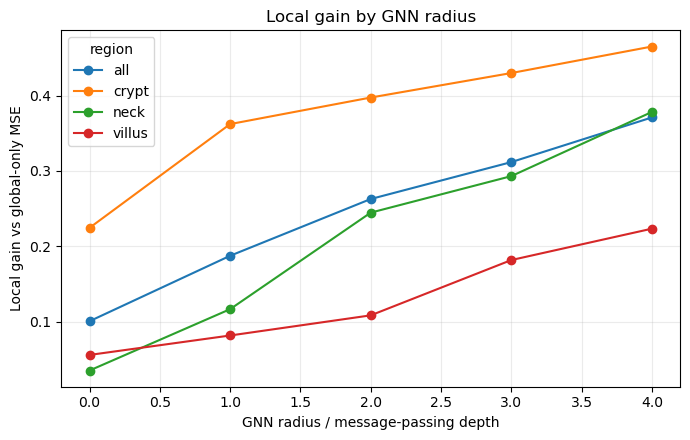

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/delta_r2_vs_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/delta_r2_vs_radius.pdf


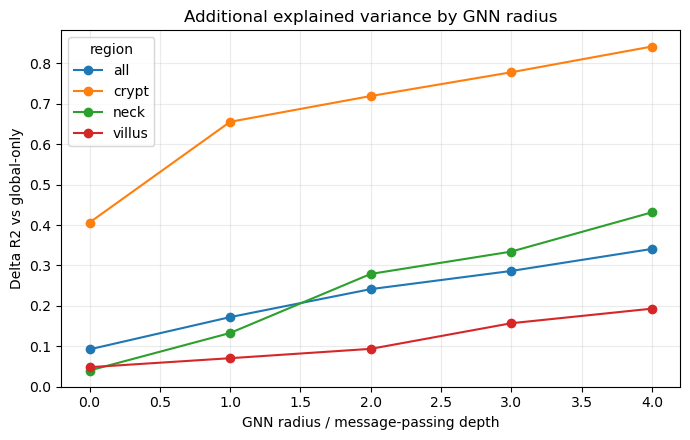

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/rmse_vs_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/rmse_vs_radius.pdf


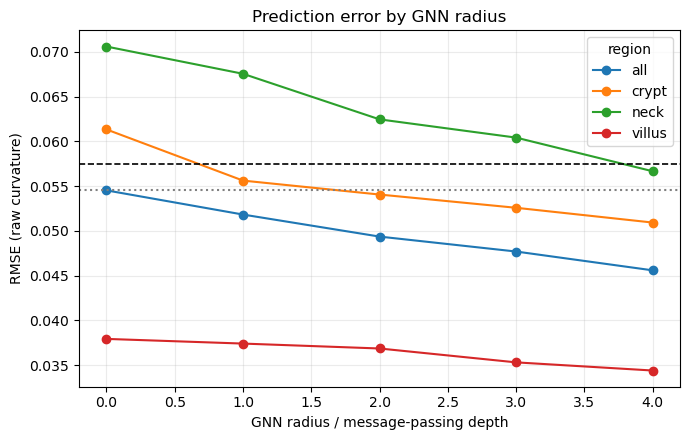

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Prediction error by GNN radius'}, xlabel='GNN radius / message-passing depth', ylabel='RMSE (raw curvature)'>)

In [18]:
def plot_lines_by_region(df, y_col, ylabel, title, filename, *, hline_cols=None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for region in REGION_ORDER:
        sub = df[df["region"] == region].sort_values("radius")
        ax.plot(sub["radius"], sub[y_col], marker="o", label=region)
    ax.set_xlabel("GNN radius / message-passing depth")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(title="region")
    if hline_cols:
        for col, style in hline_cols:
            base = df[(df["region"] == "all") & (df["radius"] == df["radius"].min())]
            if len(base) and np.isfinite(base[col].iloc[0]):
                ax.axhline(base[col].iloc[0], **style)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


plot_lines_by_region(
    predictive_gain_df,
    "local_gain_vs_global",
    "Local gain vs global-only MSE",
    "Local gain by GNN radius",
    "local_gain_vs_radius",
)
plot_lines_by_region(
    predictive_gain_df,
    "delta_r2_vs_global",
    "Delta R2 vs global-only",
    "Additional explained variance by GNN radius",
    "delta_r2_vs_radius",
)
plot_lines_by_region(
    predictive_gain_df,
    "rmse_gnn",
    "RMSE (raw curvature)",
    "Prediction error by GNN radius",
    "rmse_vs_radius",
    hline_cols=[
        ("rmse_global", {"color": "black", "linestyle": "--", "linewidth": 1.2, "label": "global-only"}),
        ("rmse_center_global", {"color": "gray", "linestyle": ":", "linewidth": 1.5, "label": "center+global"}),
    ],
)


## 6. Neighborhood Coherence Analysis

This is related to clustering final node embeddings, but more local. Broad clusters can have high curvature variance because they contain multiple substructures. The kNN variance asks whether very similar learned neighborhoods have similar curvature.

For each validation cell, we form a query vector

$$q_i = concat(z_i, normalized\ global\ features_i),$$

fit normalization using training cells only, find the `k` nearest training cells, and compute the variance of the neighbors' true curvature. The coherence score is

$$NeighborhoodCoherence_r = 1 - \frac{mean(local\_var_i)}{Var(y_{true, group})}.$$

High coherence means similar observed neighborhoods correspond to similar curvatures. Low coherence means the same learned neighborhood representation is compatible with many curvature values.


In [19]:
def make_query_space(embeddings, split):
    local = np.asarray(embeddings[f"{split}_local"], dtype=np.float32)
    g = embeddings.get(f"{split}_global")
    if g is None:
        return local
    g = np.asarray(g, dtype=np.float32)
    return np.concatenate([local, g], axis=1)


def compute_neighbor_local_variance(q_train, y_train, q_val, *, k):
    q_train = np.asarray(q_train, dtype=float)
    q_val = np.asarray(q_val, dtype=float)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    if q_train.shape[0] != y_train.shape[0]:
        raise ValueError("Training query and target lengths differ.")
    if q_train.shape[0] < int(k):
        warnings.warn(f"Only {q_train.shape[0]} training cells available; cannot use k={k}.")
        return np.full(q_val.shape[0], np.nan, dtype=float)

    scaler = StandardScaler().fit(q_train)
    q_train_scaled = scaler.transform(q_train)
    q_val_scaled = scaler.transform(q_val)
    nn = NearestNeighbors(n_neighbors=int(k), metric="euclidean")
    nn.fit(q_train_scaled)
    indices = nn.kneighbors(q_val_scaled, return_distance=False)
    neighbor_values = y_train[indices]
    return np.var(neighbor_values, axis=1, ddof=1 if int(k) > 1 else 0)


def summarize_coherence(meta_df, local_var, y_true, *, radius, k):
    rows = []
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    local_var = np.asarray(local_var, dtype=float).reshape(-1)
    for region in REGION_ORDER:
        mask = np.ones(len(meta_df), dtype=bool) if region == "all" else (meta_df[REGION_COL].to_numpy() == region)
        n = int(mask.sum())
        n_org = int(meta_df.loc[mask, ORGANOID_ID_COLUMN].nunique()) if n else 0
        if n < 3 or n_org < 1:
            group_var = mean_local = coherence = np.nan
        else:
            group_y = y_true[mask]
            group_var = float(np.var(group_y[np.isfinite(group_y)], ddof=1)) if np.sum(np.isfinite(group_y)) > 1 else np.nan
            mean_local = float(np.nanmean(local_var[mask])) if np.any(np.isfinite(local_var[mask])) else np.nan
            coherence = 1.0 - mean_local / group_var if group_var and np.isfinite(group_var) and group_var > 0 else np.nan
        rows.append({
            "timepoint": TIMEPOINT_LABEL,
            "region": region,
            "radius": int(radius),
            "k": int(k),
            "mean_local_neighbor_variance": mean_local,
            "group_curvature_variance": group_var,
            "neighborhood_coherence": coherence,
            "n_cells": n,
            "n_organoids": n_org,
        })
    return rows


coherence_rows = []
local_neighbor_variance_by_radius_k = {}
for radius, embeddings in sorted(embedding_by_radius.items()):
    q_train = make_query_space(embeddings, "train")
    q_val = make_query_space(embeddings, "val")
    y_train_raw = train_predictions[radius]["y_true"]
    y_val_raw = gnn_predictions[radius]["y_true"]
    assert q_train.shape[0] == len(train_metadata_df)
    assert q_val.shape[0] == len(val_metadata_df)
    # q_train and q_val are built from disjoint graph lists, so validation cells are never kNN references.
    for k in K_VALUES:
        local_var = compute_neighbor_local_variance(q_train, y_train_raw, q_val, k=k)
        local_neighbor_variance_by_radius_k[(int(radius), int(k))] = local_var
        coherence_rows.extend(summarize_coherence(val_metadata_df, local_var, y_val_raw, radius=radius, k=k))

coherence_df = pd.DataFrame(coherence_rows)
display(coherence_df)


,timepoint,region,radius,k,mean_local_neighbor_variance,group_curvature_variance,neighborhood_coherence,n_cells,n_organoids
0,single_timepoint,all,0,25,0.002712,0.003597,0.246073,75372,141
1,single_timepoint,crypt,0,25,0.003009,0.002680,-0.122466,16476,133
2,single_timepoint,neck,0,25,0.002815,0.004528,0.378273,21825,133
3,single_timepoint,villus,0,25,0.002520,0.001763,-0.428915,37071,138
4,single_timepoint,all,0,50,0.002781,0.003597,0.226856,75372,141
5,single_timepoint,crypt,0,50,0.003077,0.002680,-0.147952,16476,133
6,single_timepoint,neck,0,50,0.002935,0.004528,0.351653,21825,133
7,single_timepoint,villus,0,50,0.002559,0.001763,-0.451166,37071,138
8,single_timepoint,all,0,100,0.002806,0.003597,0.219832,75372,141
9,single_timepoint,crypt,0,100,0.003210,0.002680,-0.197793,16476,133


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/neighborhood_coherence_vs_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/neighborhood_coherence_vs_radius.pdf


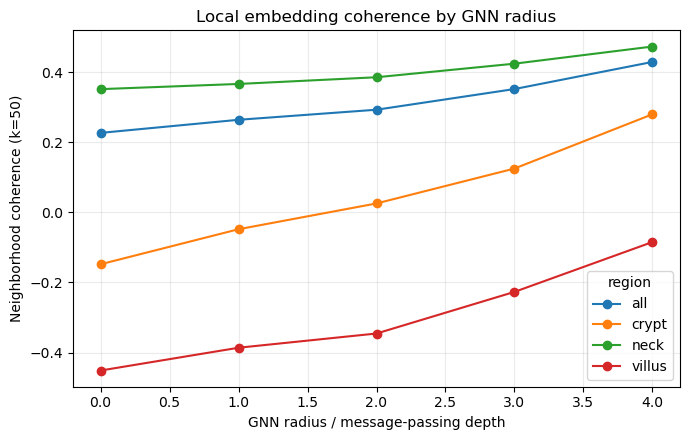

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/mean_local_neighbor_variance_vs_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/mean_local_neighbor_variance_vs_radius.pdf


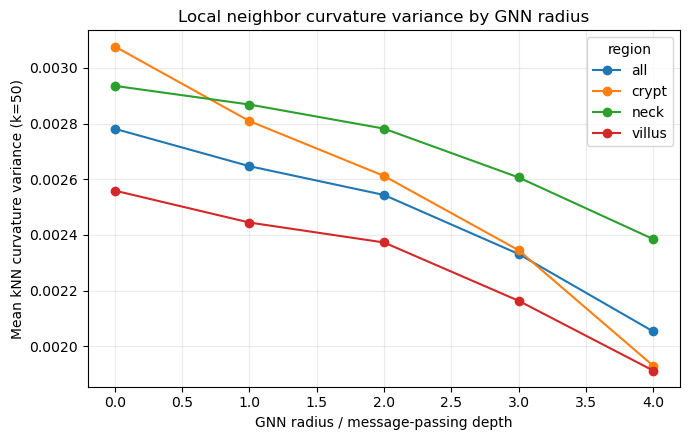

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/neighborhood_coherence_k_sensitivity.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/neighborhood_coherence_k_sensitivity.pdf


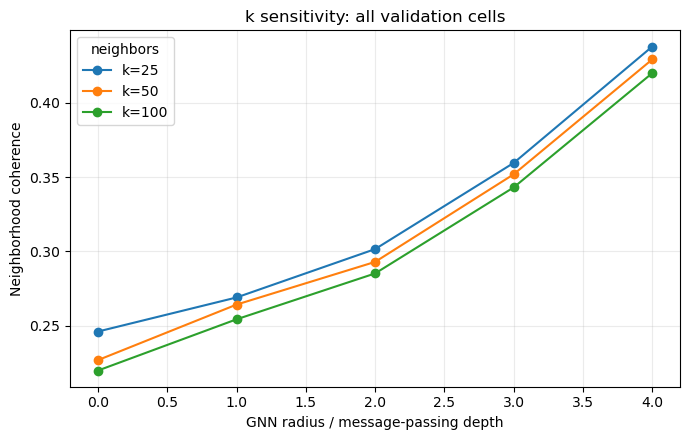

In [20]:
coherence_main_df = coherence_df[coherence_df["k"] == DEFAULT_K].copy()
plot_lines_by_region(
    coherence_main_df,
    "neighborhood_coherence",
    f"Neighborhood coherence (k={DEFAULT_K})",
    "Local embedding coherence by GNN radius",
    "neighborhood_coherence_vs_radius",
)
plot_lines_by_region(
    coherence_main_df,
    "mean_local_neighbor_variance",
    f"Mean kNN curvature variance (k={DEFAULT_K})",
    "Local neighbor curvature variance by GNN radius",
    "mean_local_neighbor_variance_vs_radius",
)

fig, ax = plt.subplots(figsize=(7, 4.5))
for k in K_VALUES:
    sub = coherence_df[(coherence_df["region"] == "all") & (coherence_df["k"] == k)].sort_values("radius")
    ax.plot(sub["radius"], sub["neighborhood_coherence"], marker="o", label=f"k={k}")
ax.set_xlabel("GNN radius / message-passing depth")
ax.set_ylabel("Neighborhood coherence")
ax.set_title("k sensitivity: all validation cells")
ax.grid(True, alpha=0.25)
ax.legend(title="neighbors")
fig.tight_layout()
save_mpl_figure(fig, "neighborhood_coherence_k_sensitivity")
plt.show()


## 7. Marker-Resolved Neighborhood Coherence

Region-level coherence can hide which cell states are intrinsically regular and which ones become regular only after the GNN sees a larger neighborhood. This section repeats the same kNN coherence calculation for each marker-positive cell group.

For each marker, validation cells with that marker active are grouped after prediction. The marker label is not passed to the neighbor search except through the original marker channels already available to the model. The score is still computed from training-cell neighbors only:

$$MarkerCoherence_{m,r} = 1 - \frac{mean(local\_var_i \mid x_{i,m} > 0.5)}{Var(y_i \mid x_{i,m} > 0.5)}.$$

Interpretation:

- Low marker curvature variance means that marker-positive cells are already regular in raw curvature.
- Falling kNN variance with radius means the learned neighborhood representation is making that marker-positive population locally more consistent.
- Rising marker coherence means nearest training neighbors explain more of the marker-positive group's curvature spread.
- Negative coherence means the marker-positive group is more homogeneous as a whole than the local neighborhoods found in embedding space.


In [21]:
def graph_marker_matrix(graphs_in):
    return np.concatenate(
        [g.x.detach().cpu().numpy().astype(np.float32) for g in graphs_in],
        axis=0,
    )


train_marker_matrix = graph_marker_matrix(g_train)
val_marker_matrix = graph_marker_matrix(g_val)

assert val_marker_matrix.shape[0] == len(val_metadata_df)
assert train_marker_matrix.shape[0] == len(train_metadata_df)
assert val_marker_matrix.shape[1] == len(marker_names)


def summarize_marker_coherence(meta_df, marker_matrix, local_var, y_true, *, radius, k, min_cells=30):
    rows = []
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    local_var = np.asarray(local_var, dtype=float).reshape(-1)
    marker_matrix = np.asarray(marker_matrix)
    for marker_index, marker_name in enumerate(marker_names):
        mask = marker_matrix[:, marker_index] > 0.5
        n = int(mask.sum())
        n_org = int(meta_df.loc[mask, ORGANOID_ID_COLUMN].nunique()) if n else 0
        if n < int(min_cells):
            group_var = mean_local = coherence = np.nan
        else:
            group_y = y_true[mask]
            finite_y = np.isfinite(group_y)
            group_var = float(np.var(group_y[finite_y], ddof=1)) if np.sum(finite_y) > 1 else np.nan
            marker_local_var = local_var[mask]
            mean_local = float(np.nanmean(marker_local_var)) if np.any(np.isfinite(marker_local_var)) else np.nan
            coherence = 1.0 - mean_local / group_var if group_var and np.isfinite(group_var) and group_var > 0 else np.nan
        rows.append({
            "timepoint": TIMEPOINT_LABEL,
            "marker": marker_name,
            "marker_index": int(marker_index),
            "radius": int(radius),
            "k": int(k),
            "mean_local_neighbor_variance": mean_local,
            "marker_curvature_variance": group_var,
            "marker_neighborhood_coherence": coherence,
            "n_cells": n,
            "n_organoids": n_org,
        })
    return rows


marker_coherence_rows = []
for radius in sorted(gnn_predictions):
    y_val_raw = gnn_predictions[radius]["y_true"]
    for k in K_VALUES:
        local_var = local_neighbor_variance_by_radius_k[(int(radius), int(k))]
        marker_coherence_rows.extend(
            summarize_marker_coherence(
                val_metadata_df,
                val_marker_matrix,
                local_var,
                y_val_raw,
                radius=radius,
                k=k,
            )
        )

marker_coherence_df = pd.DataFrame(marker_coherence_rows)
display(marker_coherence_df.head(12))


,timepoint,marker,marker_index,radius,k,mean_local_neighbor_variance,marker_curvature_variance,marker_neighborhood_coherence,n_cells,n_organoids
0,single_timepoint,Agr2,0,0,25,0.003034,0.003860,0.213862,3322,138
1,single_timepoint,AldoB,1,0,25,0.002317,0.002593,0.106546,27495,130
2,single_timepoint,Chroma,2,0,25,0.003375,0.004832,0.301422,352,86
3,single_timepoint,KI67,3,0,25,0.002567,0.003667,0.300032,24067,140
4,single_timepoint,LGR5,4,0,25,0.002629,0.003457,0.239531,11003,128
5,single_timepoint,Lysozyme,5,0,25,0.002781,0.003954,0.296686,1819,130
6,single_timepoint,Serotonin,6,0,25,0.003856,0.004204,0.082963,302,108
7,single_timepoint,Agr2,0,0,50,0.003078,0.003860,0.202582,3322,138
8,single_timepoint,AldoB,1,0,50,0.002206,0.002593,0.149133,27495,130
9,single_timepoint,Chroma,2,0,50,0.003597,0.004832,0.255574,352,86


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_neighborhood_coherence_heatmap.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_neighborhood_coherence_heatmap.pdf


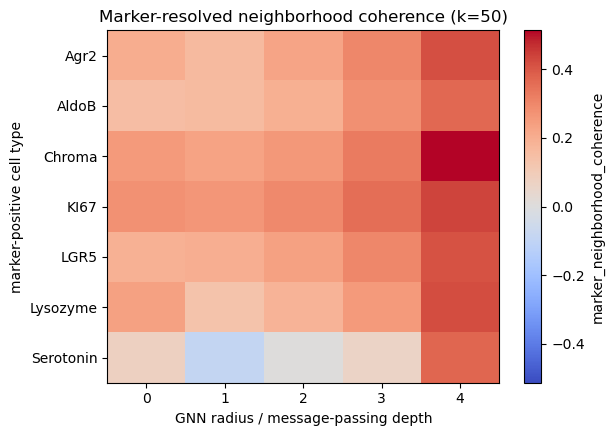

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_mean_local_neighbor_variance_heatmap.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_mean_local_neighbor_variance_heatmap.pdf


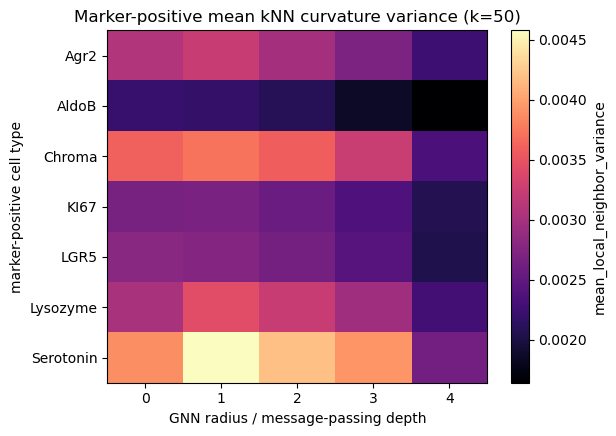

,marker,marker_index,marker_curvature_variance,n_cells,n_organoids
1,AldoB,1,0.002593,27495,130
4,LGR5,4,0.003457,11003,128
3,KI67,3,0.003667,24067,140
0,Agr2,0,0.003860,3322,138
5,Lysozyme,5,0.003954,1819,130
6,Serotonin,6,0.004204,302,108
2,Chroma,2,0.004832,352,86


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_intrinsic_curvature_variance.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_intrinsic_curvature_variance.pdf


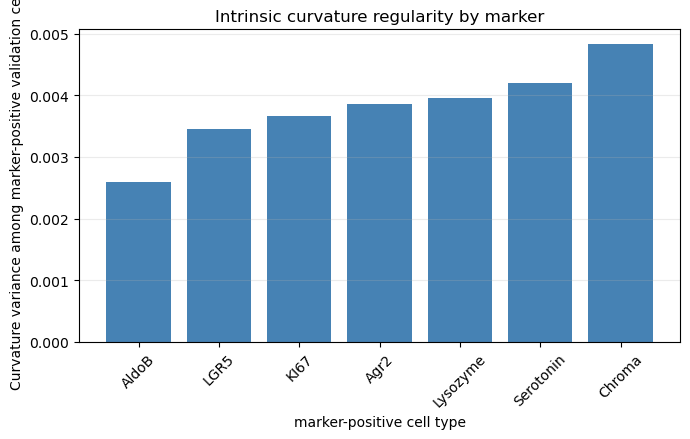

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_coherence_selected_trajectories.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/marker_coherence_selected_trajectories.pdf


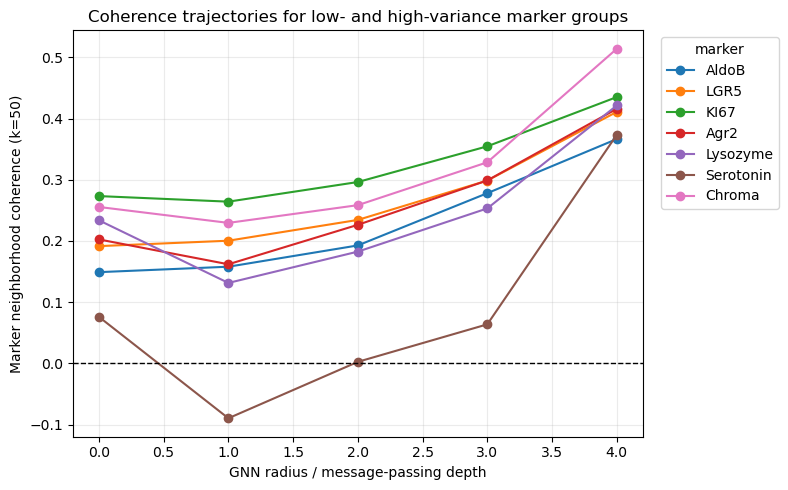

In [22]:
def plot_marker_radius_heatmap(df, value_col, title, filename, *, k=DEFAULT_K, cmap="viridis", center_zero=False):
    sub = df[df["k"] == k].copy()
    table = (
        sub.pivot(index="marker", columns="radius", values=value_col)
        .reindex(index=marker_names)
        .sort_index(axis=1)
    )
    values = table.to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(values)):
        vmax = float(np.nanmax(np.abs(values)))
        vmin = -vmax
    else:
        vmin = vmax = None

    fig, ax = plt.subplots(figsize=(max(6, 0.75 * table.shape[1] + 2.5), max(4, 0.38 * table.shape[0] + 1.8)))
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_xlabel("GNN radius / message-passing depth")
    ax.set_ylabel("marker-positive cell type")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_col)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


marker_main_df = marker_coherence_df[marker_coherence_df["k"] == DEFAULT_K].copy()
plot_marker_radius_heatmap(
    marker_coherence_df,
    "marker_neighborhood_coherence",
    f"Marker-resolved neighborhood coherence (k={DEFAULT_K})",
    "marker_neighborhood_coherence_heatmap",
    k=DEFAULT_K,
    cmap="coolwarm",
    center_zero=True,
)
plot_marker_radius_heatmap(
    marker_coherence_df,
    "mean_local_neighbor_variance",
    f"Marker-positive mean kNN curvature variance (k={DEFAULT_K})",
    "marker_mean_local_neighbor_variance_heatmap",
    k=DEFAULT_K,
    cmap="magma",
)

# Marker intrinsic curvature variance is independent of radius for fixed validation data;
# keep one row per marker for a direct regularity ranking.
marker_variance_df = (
    marker_main_df
    .sort_values("radius")
    .groupby(["marker", "marker_index"], as_index=False)
    .first()[["marker", "marker_index", "marker_curvature_variance", "n_cells", "n_organoids"]]
    .sort_values("marker_curvature_variance")
)

display(marker_variance_df)

fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(marker_variance_df)), 4.5))
ax.bar(marker_variance_df["marker"], marker_variance_df["marker_curvature_variance"], color="steelblue")
ax.set_ylabel("Curvature variance among marker-positive validation cells")
ax.set_xlabel("marker-positive cell type")
ax.set_title("Intrinsic curvature regularity by marker")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
save_mpl_figure(fig, "marker_intrinsic_curvature_variance")
plt.show()

# Plot coherence trajectories for the most and least intrinsically variable markers.
n_show = min(5, len(marker_variance_df))
markers_to_show = pd.unique(pd.concat([
    marker_variance_df.head(n_show)["marker"],
    marker_variance_df.tail(n_show)["marker"],
], ignore_index=True))

fig, ax = plt.subplots(figsize=(8, 5))
for marker in markers_to_show:
    sub = marker_main_df[marker_main_df["marker"] == marker].sort_values("radius")
    ax.plot(sub["radius"], sub["marker_neighborhood_coherence"], marker="o", label=marker)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("GNN radius / message-passing depth")
ax.set_ylabel(f"Marker neighborhood coherence (k={DEFAULT_K})")
ax.set_title("Coherence trajectories for low- and high-variance marker groups")
ax.grid(True, alpha=0.25)
ax.legend(title="marker", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_mpl_figure(fig, "marker_coherence_selected_trajectories")
plt.show()


## 8. Optional Uncertainty Calibration Analysis

The current models usually output a Gaussian mean and predictive variance. Calibration is checked by comparing predicted variance to squared residuals, standardized residual variance, and empirical coverage of nominal Gaussian intervals. Calibrated high predicted variance in crypts would support the interpretation that crypt curvature is conditionally harder to infer from the available inputs.


In [23]:
def summarize_uncertainty(df, *, region):
    sub = df.copy() if region == "all" else df[df[REGION_COL] == region].copy()
    sub = sub[np.isfinite(sub["y_var_pred"]) & (sub["y_var_pred"] > 0)]
    n = int(len(sub))
    n_org = int(sub[ORGANOID_ID_COLUMN].nunique()) if n else 0
    if n == 0:
        return {
            "pred_var_mean": np.nan,
            "sqerr_mean": np.nan,
            "standardized_residual_variance": np.nan,
            "coverage_68": np.nan,
            "coverage_95": np.nan,
            "n_cells": 0,
            "n_organoids": 0,
        }
    residual = sub["y_true"].to_numpy(dtype=float) - sub["y_pred"].to_numpy(dtype=float)
    var = sub["y_var_pred"].to_numpy(dtype=float)
    z = residual / np.sqrt(var + 1e-12)
    return {
        "pred_var_mean": float(np.mean(var)),
        "sqerr_mean": float(np.mean(residual ** 2)),
        "standardized_residual_variance": float(np.var(z, ddof=1)) if n > 1 else np.nan,
        "coverage_68": float(np.mean(np.abs(residual) <= 1.0 * np.sqrt(var))),
        "coverage_95": float(np.mean(np.abs(residual) <= 1.96 * np.sqrt(var))),
        "n_cells": n,
        "n_organoids": n_org,
    }


uncertainty_rows = []
for radius in sorted(gnn_predictions):
    df = val_metadata_df.copy()
    df["radius"] = int(radius)
    df["y_true"] = gnn_predictions[radius]["y_true"]
    df["y_pred"] = gnn_predictions[radius]["y_pred"]
    df["y_var_pred"] = gnn_predictions[radius]["pred_var"]
    if df["y_var_pred"].isna().all():
        continue
    for region in REGION_ORDER:
        row = {"timepoint": TIMEPOINT_LABEL, "region": region, "radius": int(radius)}
        row.update(summarize_uncertainty(df, region=region))
        uncertainty_rows.append(row)

uncertainty_df = pd.DataFrame(uncertainty_rows)
display(uncertainty_df)


,timepoint,region,radius,pred_var_mean,sqerr_mean,standardized_residual_variance,coverage_68,coverage_95,n_cells,n_organoids
0,single_timepoint,all,0,0.001394,0.002973,1.966649,0.631640,0.873560,75372,141
1,single_timepoint,crypt,0,0.001698,0.003761,1.268673,0.506858,0.829449,16476,133
2,single_timepoint,neck,0,0.001449,0.004982,2.432664,0.547537,0.795693,21825,133
3,single_timepoint,villus,0,0.001227,0.001439,1.144934,0.736614,0.939009,37071,138
4,single_timepoint,all,1,0.001544,0.002685,1.747476,0.655973,0.889269,75372,141
5,single_timepoint,crypt,1,0.002019,0.003093,1.186942,0.563729,0.865501,16476,133
6,single_timepoint,neck,1,0.001639,0.004562,2.185510,0.567010,0.818923,21825,133
7,single_timepoint,villus,1,0.001276,0.001400,1.092897,0.749346,0.941248,37071,138
8,single_timepoint,all,2,0.001552,0.002436,1.743417,0.654872,0.892016,75372,141
9,single_timepoint,crypt,2,0.001770,0.002922,1.332916,0.543214,0.850024,16476,133


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/predicted_variance_by_region_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/predicted_variance_by_region_radius.pdf


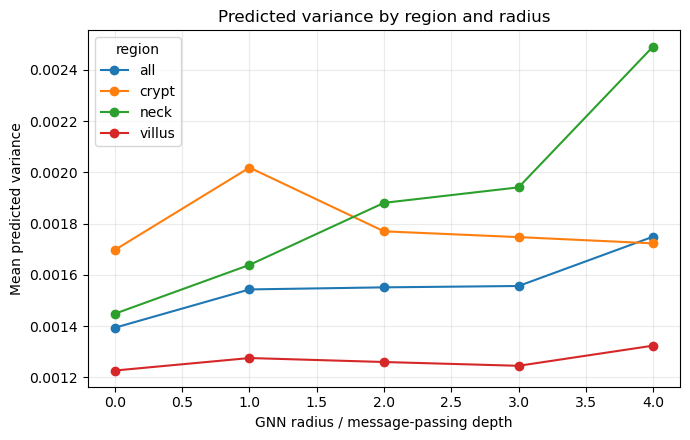

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/standardized_residual_variance_by_region_radius.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/standardized_residual_variance_by_region_radius.pdf


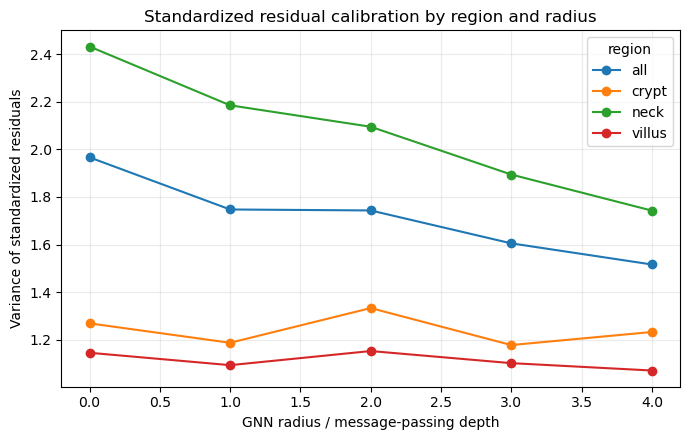

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/variance_vs_sqerr_binned_radius_4.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/variance_vs_sqerr_binned_radius_4.pdf


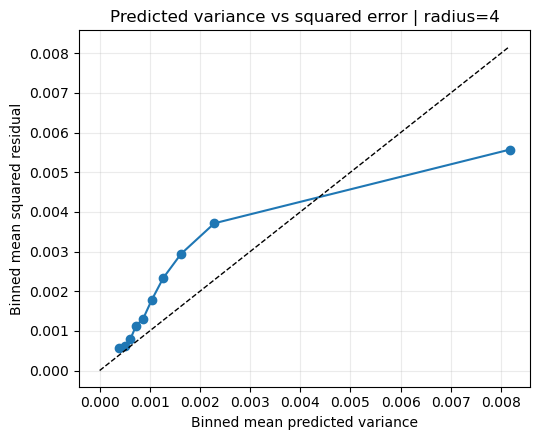

In [24]:
if len(uncertainty_df):
    plot_lines_by_region(
        uncertainty_df,
        "pred_var_mean",
        "Mean predicted variance",
        "Predicted variance by region and radius",
        "predicted_variance_by_region_radius",
    )
    plot_lines_by_region(
        uncertainty_df,
        "standardized_residual_variance",
        "Variance of standardized residuals",
        "Standardized residual calibration by region and radius",
        "standardized_residual_variance_by_region_radius",
    )

    radius = max(RADII)
    df = val_metadata_df.copy()
    df["y_true"] = gnn_predictions[radius]["y_true"]
    df["y_pred"] = gnn_predictions[radius]["y_pred"]
    df["y_var_pred"] = gnn_predictions[radius]["pred_var"]
    df["sqerr"] = (df["y_true"] - df["y_pred"]) ** 2
    df = df[np.isfinite(df["y_var_pred"]) & np.isfinite(df["sqerr"])]
    df["pred_var_bin"] = pd.qcut(df["y_var_pred"], q=10, duplicates="drop")
    binned = df.groupby("pred_var_bin", observed=True).agg(
        pred_var_mean=("y_var_pred", "mean"),
        sqerr_mean=("sqerr", "mean"),
        n_cells=("sqerr", "size"),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.plot(binned["pred_var_mean"], binned["sqerr_mean"], marker="o")
    lim = float(np.nanmax([binned["pred_var_mean"].max(), binned["sqerr_mean"].max()]))
    ax.plot([0, lim], [0, lim], color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Binned mean predicted variance")
    ax.set_ylabel("Binned mean squared residual")
    ax.set_title(f"Predicted variance vs squared error | radius={radius}")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    save_mpl_figure(fig, f"variance_vs_sqerr_binned_radius_{radius}")
    plt.show()
else:
    print("No predictive variance available; skipping uncertainty plots.")


## 9. Combined Summary Figures

The final summary places the central quantities side by side: local predictive gain, region-level embedding coherence, and marker-resolved embedding coherence. The marker panel summarizes the average marker-positive coherence across cell types, which is useful as a compact view of whether larger neighborhoods regularize cell-type-specific curvature variance.


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/neighborhood_predictability_summary.png and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/neighborhood_predictability_analysis/run_20260602_151744/figures/neighborhood_predictability_summary.pdf


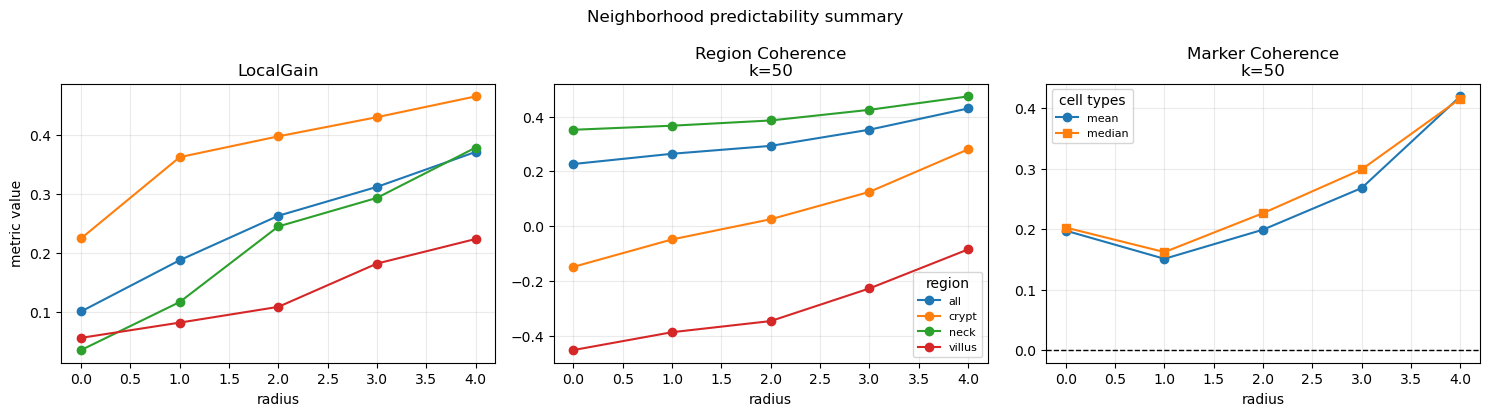

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
summary_specs = [
    (predictive_gain_df, "local_gain_vs_global", "LocalGain", "region"),
    (coherence_main_df, "neighborhood_coherence", f"Region Coherence\nk={DEFAULT_K}", "region"),
]
for ax, (df, col, title, group_col) in zip(axes[:2], summary_specs):
    for region in REGION_ORDER:
        sub = df[df[group_col] == region].sort_values("radius")
        ax.plot(sub["radius"], sub[col], marker="o", label=region)
    ax.set_title(title)
    ax.set_xlabel("radius")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("metric value")
axes[1].legend(title="region", fontsize=8)

marker_summary_df = (
    marker_main_df
    .groupby("radius", as_index=False)
    .agg(
        mean_marker_coherence=("marker_neighborhood_coherence", "mean"),
        median_marker_coherence=("marker_neighborhood_coherence", "median"),
    )
)
axes[2].plot(marker_summary_df["radius"], marker_summary_df["mean_marker_coherence"], marker="o", label="mean")
axes[2].plot(marker_summary_df["radius"], marker_summary_df["median_marker_coherence"], marker="s", label="median")
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title(f"Marker Coherence\nk={DEFAULT_K}")
axes[2].set_xlabel("radius")
axes[2].grid(True, alpha=0.25)
axes[2].legend(title="cell types", fontsize=8)

fig.suptitle("Neighborhood predictability summary")
fig.tight_layout()
save_mpl_figure(fig, "neighborhood_predictability_summary")
plt.show()


## 10. Save Tables And Run Metadata

All summary tables include a `timepoint` column. With more developmental stages, the same notebook can be lifted into a loop over timepoints and the figures can be faceted by that column.


In [ ]:
# predictive_gain_df.to_csv(TABLES_DIR / "predictive_gain.csv", index=False)
# coherence_df.to_csv(TABLES_DIR / "neighborhood_coherence.csv", index=False)
# marker_coherence_df.to_csv(TABLES_DIR / "marker_neighborhood_coherence.csv", index=False)
# marker_variance_df.to_csv(TABLES_DIR / "marker_intrinsic_curvature_variance.csv", index=False)
# baseline_metrics_df.to_csv(TABLES_DIR / "baseline_metrics_by_region.csv", index=False)
# gnn_metrics_df.to_csv(TABLES_DIR / "gnn_metrics_by_region.csv", index=False)
# predictions_df.to_csv(TABLES_DIR / "validation_predictions_tidy.csv", index=False)
# validation_predictions_wide_df.to_csv(TABLES_DIR / "validation_predictions_wide.csv", index=False)
# region_count_df.to_csv(TABLES_DIR / "region_counts.csv", index=False)
# if len(uncertainty_df):
#     uncertainty_df.to_csv(TABLES_DIR / "uncertainty_calibration.csv", index=False)

# experiment_config = {
#     **CONFIG,
#     "dataset_name": DATASET_NAME,
#     "use_global_features": USE_GLOBAL_FEATURES,
#     "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
#     "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
#     "target_transform": target_transform.name,
#     "split": {
#         "val_frac": VAL_FRAC,
#         "split_seed": SPLIT_SEED,
#         "forced_val_keys": sorted(list(FORCED_VAL_KEYS)),
#         "n_train_graphs": len(g_train),
#         "n_val_graphs": len(g_val),
#     },
#     "filters": {
#         "excluded_timepoints": sorted(EXCLUDED_TIMEPOINTS),
#         "blacklist_n_keys": len(blacklist),
#         "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
#         "sphericity_max": SPHERICITY_MAX,
#         "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
#         "complexity_min": COMPLEXITY_MIN,
#         "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
#         "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
#     },
#     "model": {
#         "class": MODEL_CLASS,
#         "hidden_dim": HIDDEN_DIM,
#         "dropout": DROPOUT,
#         "norm": NORM,
#         "residual": RESIDUAL,
#     },
#     "training": {
#         "lr": LR,
#         "batch_size": BATCH_SIZE,
#         "max_epochs": MAX_EPOCHS,
#         "patience": PATIENCE,
#         "num_workers": NUM_WORKERS,
#         "edge_loss_weight": EDGE_LOSS_WEIGHT,
#         "edge_loss_params": EDGE_LOSS_PARAMS,
#     },
#     "marker_names": list(marker_names),
#     "field_specs": field_specs,
#     "figures_dir": str(FIGURES_DIR),
#     "tables_dir": str(TABLES_DIR),
# }

# experiment_results = {
#     "predictive_gain_df": predictive_gain_df,
#     "coherence_df": coherence_df,
#     "marker_coherence_df": marker_coherence_df,
#     "marker_variance_df": marker_variance_df,
#     "uncertainty_df": uncertainty_df,
#     "baseline_metrics_df": baseline_metrics_df,
#     "gnn_metrics_df": gnn_metrics_df,
#     "region_count_df": region_count_df,
#     "split_info": split_info,
#     "outlier_info": outlier_info,
#     "gnn_training_logs": gnn_training_logs,
#     "metrics_global_baseline": metrics_global_baseline,
#     "metrics_center_global": metrics_center_global,
# }

# with open(SAVE_DIR / "config.json", "w") as f:
#     json.dump(jsonable(experiment_config), f, indent=2)
# with open(SAVE_DIR / "results.pkl", "wb") as f:
#     pickle.dump(experiment_results, f)
# with open(SAVE_DIR / "meta.json", "w") as f:
#     json.dump({"timestamp": datetime.now().isoformat(), "notes": "Neighborhood predictability analysis with marker-resolved coherence."}, f, indent=2)

# print(f"Saved experiment -> {SAVE_DIR}")


TypeError: Object of type dtype is not JSON serializable